In [15]:
# Import packages and modules
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow_decision_forests as tfdf

from sklearn.model_selection import train_test_split

In [16]:
# Check the version of TensorFlow Decision Forests
print("Found TensorFlow Decision Forests v" + tfdf.__version__)

Found TensorFlow Decision Forests v1.9.1


In [17]:
# train/validation/test = 70/10/20
dataset = pd.read_csv('dataset/firstorder/kernel5-radius5/dataset.csv')

train_data, temp_data = train_test_split(
    dataset, test_size=0.3, random_state=42
 )
validation_data, test_data = train_test_split(
    temp_data, test_size=2/3, random_state=42
 )

In [18]:
# Convert the dataset into a TensorFlow dataset.
train_ds = tfdf.keras.pd_dataframe_to_tf_dataset(
    train_data, label="label"
)         
val_ds = tfdf.keras.pd_dataframe_to_tf_dataset(
    validation_data, label="label"
)
test_ds = tfdf.keras.pd_dataframe_to_tf_dataset(
    test_data, label="label"
)

In [19]:
import keras

In [20]:
%%time

# Train a Gradient Boosted Trees model.
model = tfdf.keras.GradientBoostedTreesModel()

# Add evaluation metrics
model.compile(
    metrics=["accuracy"]
)
model.fit(x=train_ds)

# # Train a Gradient Boosted Trees model.
# model = tfdf.keras.GradientBoostedTreesModel(num_trees=1500)
# model.fit(train_ds)

Use /tmp/tmp_5d7i2e1 as temporary training directory
Reading training dataset...


[WARNING 26-05-18 17:50:30.2568 UTC gradient_boosted_trees.cc:1840] "goss_alpha" set but "sampling_method" not equal to "GOSS".
[WARNING 26-05-18 17:50:30.2573 UTC gradient_boosted_trees.cc:1851] "goss_beta" set but "sampling_method" not equal to "GOSS".
[WARNING 26-05-18 17:50:30.2573 UTC gradient_boosted_trees.cc:1865] "selective_gradient_boosting_ratio" set but "sampling_method" not equal to "SELGB".


Training dataset read in 0:00:00.696537. Found 78712 examples.
Training model...
Model trained in 0:00:15.940479
Compiling model...


[INFO 26-05-18 17:50:46.9126 UTC kernel.cc:1233] Loading model from path /tmp/tmp_5d7i2e1/model/ with prefix ce2ff6c425ce4391
[INFO 26-05-18 17:50:46.9239 UTC quick_scorer_extended.cc:911] The binary was compiled without AVX2 support, but your CPU supports it. Enable it for faster model inference.
[INFO 26-05-18 17:50:46.9248 UTC abstract_model.cc:1362] Engine "GradientBoostedTreesQuickScorerExtended" built
[INFO 26-05-18 17:50:46.9248 UTC kernel.cc:1061] Use fast generic engine


Model compiled.
CPU times: user 1min 27s, sys: 3.14 s, total: 1min 31s
Wall time: 17 s


In [21]:
# Evaluate the model
evaluate = model.evaluate(val_ds, return_dict=True)
print()

for name, value in evaluate.items():
    print(f"{name}: {value:.4f}")

12/12 [==============================] - 0s 6ms/step - loss: 0.0000e+00 - accuracy: 0.9588

loss: 0.0000
accuracy: 0.9588


In [22]:
# Model Summary
model.summary()

Model: "gradient_boosted_trees_model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
Total params: 1 (1.00 Byte)
Trainable params: 0 (0.00 Byte)
Non-trainable params: 1 (1.00 Byte)
_________________________________________________________________
Type: "GRADIENT_BOOSTED_TREES"
Task: CLASSIFICATION
Label: "__LABEL"

Input Features (18):
	10Percentile
	90Percentile
	Energy
	Entropy
	InterquartileRange
	Kurtosis
	Maximum
	Mean
	MeanAbsoluteDeviation
	Median
	Minimum
	Range
	RobustMeanAbsoluteDeviation
	RootMeanSquared
	Skewness
	TotalEnergy
	Uniformity
	Variance

No weights

Variable Importance: INV_MEAN_MIN_DEPTH:
    1.                      "Median"  0.222057 ################
    2.                     "Maximum"  0.212498 ############
    3.                     "Minimum"  0.207214 ##########
    4.                    "Variance"  0.206526 #########
    5.                       "Range"  0.202078 #######

In [23]:
# Model features
model.make_inspector().features()

["10Percentile" (1; #0),
 "90Percentile" (1; #1),
 "Energy" (1; #2),
 "Entropy" (1; #3),
 "InterquartileRange" (1; #4),
 "Kurtosis" (1; #5),
 "Maximum" (1; #6),
 "Mean" (1; #7),
 "MeanAbsoluteDeviation" (1; #8),
 "Median" (1; #9),
 "Minimum" (1; #10),
 "Range" (1; #11),
 "RobustMeanAbsoluteDeviation" (1; #12),
 "RootMeanSquared" (1; #13),
 "Skewness" (1; #14),
 "TotalEnergy" (1; #15),
 "Uniformity" (1; #16),
 "Variance" (1; #17)]

In [24]:
# Feature importance
model.make_inspector().variable_importances()

{'INV_MEAN_MIN_DEPTH': [("Median" (1; #9), 0.2220572908427369),
  ("Maximum" (1; #6), 0.21249843569576046),
  ("Minimum" (1; #10), 0.20721355908710712),
  ("Variance" (1; #17), 0.2065262823199725),
  ("Range" (1; #11), 0.20207764042214987),
  ("90Percentile" (1; #1), 0.20084471455250982),
  ("Skewness" (1; #14), 0.19961371621147478),
  ("Uniformity" (1; #16), 0.19792401566416332),
  ("Kurtosis" (1; #5), 0.1963639945528458),
  ("10Percentile" (1; #0), 0.19547054460132843),
  ("RobustMeanAbsoluteDeviation" (1; #12), 0.18965194897705098),
  ("MeanAbsoluteDeviation" (1; #8), 0.18917489492702505),
  ("TotalEnergy" (1; #15), 0.18565781820266722),
  ("Entropy" (1; #3), 0.18565224656573276),
  ("Mean" (1; #7), 0.18562291780410944),
  ("Energy" (1; #2), 0.18363286010734958),
  ("RootMeanSquared" (1; #13), 0.1827452763926056),
  ("InterquartileRange" (1; #4), 0.18074841599886426)],
 'SUM_SCORE': [("TotalEnergy" (1; #15), 3909.7104680965413),
  ("Energy" (1; #2), 2270.659776492442),
  ("RootMeanS

In [25]:
# Model self evaluation
model.make_inspector().evaluation()

Evaluation(num_examples=None, accuracy=0.9615091681480408, loss=0.239517480134964, rmse=None, ndcg=None, aucs=None, auuc=None, qini=None)

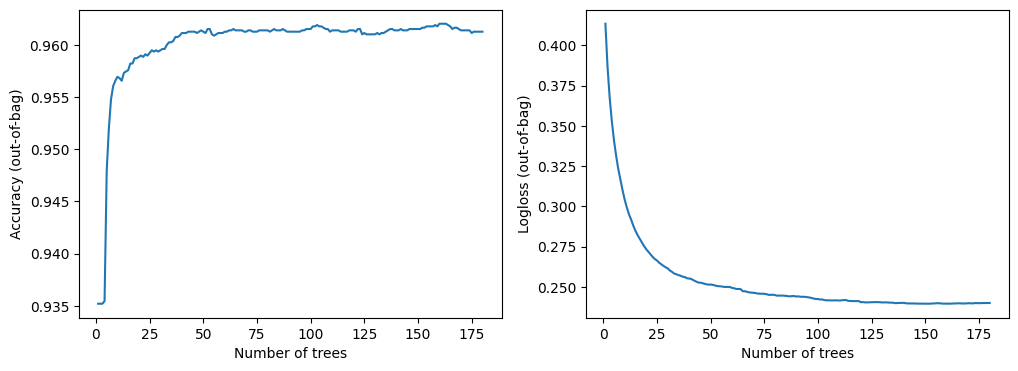

In [26]:
logs = model.make_inspector().training_logs()

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot([log.num_trees for log in logs], [log.evaluation.accuracy for log in logs])
plt.xlabel("Number of trees")
plt.ylabel("Accuracy (out-of-bag)")
plt.subplot(1, 2, 2)
plt.plot([log.num_trees for log in logs], [log.evaluation.loss for log in logs])
plt.xlabel("Number of trees")
plt.ylabel("Logloss (out-of-bag)")
plt.show()

Calculate the score of our hold-out validation dataset

In [27]:
predictions = model.predict(val_ds)
y_true      = validation_data["label"]

from sklearn.metrics import roc_auc_score
ROC_AUC = roc_auc_score(y_true, predictions)
print("The ROC AUC score is %.5f" % ROC_AUC )

12/12 [==============================] - 0s 10ms/step
The ROC AUC score is 0.92780


In [28]:
# Compute binary classification metrics with sklearn
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
    log_loss,
    brier_score_loss,
)

# Get predictions (probabilities or class labels)
preds = model.predict(test_ds)
# If model outputs probabilities, convert to labels by threshold 0.5
if preds.ndim == 2:
    # For TFDF classification, preds may be class probabilities with shape (N, 2)
    if preds.shape[1] == 2:
        pos_probs = preds[:, 1]
    else:
        # If single-probability column (positive class)
        pos_probs = preds[:, -1]
    y_pred = (pos_probs >= 0.5).astype(int)
else:
    # Already class labels
    y_pred = preds.astype(int)
    pos_probs = None

# Ground truth labels (must be 0/1 integers)
y_true = test_data["label"].astype(int).to_numpy()

# Core metrics
metrics = {}
metrics["accuracy"] = accuracy_score(y_true, y_pred)
metrics["precision"] = precision_score(y_true, y_pred, zero_division=0)
metrics["recall"] = recall_score(y_true, y_pred, zero_division=0)
metrics["f1"] = f1_score(y_true, y_pred, zero_division=0)
metrics["mcc"] = matthews_corrcoef(y_true, y_pred)

# Probabilistic metrics (only if we have probabilities)
if pos_probs is not None:
    metrics["roc_auc"] = roc_auc_score(y_true, pos_probs)
    metrics["pr_auc"] = average_precision_score(y_true, pos_probs)
    metrics["log_loss"] = log_loss(y_true, pos_probs, labels=[0,1])
    metrics["brier_score"] = brier_score_loss(y_true, pos_probs)

# Confusion matrix and detailed report
cm = confusion_matrix(y_true, y_pred, labels=[0,1])
report = classification_report(y_true, y_pred, digits=4)

print("Sklearn binary metrics:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")
print("\nConfusion matrix:\n", cm)
print("\nClassification report:\n", report)

23/23 [==============================] - 0s 10ms/step
Sklearn binary metrics:
accuracy: 0.9593
precision: 0.8364
recall: 0.5182
f1: 0.6399
mcc: 0.6396
roc_auc: 0.9296
pr_auc: 0.7144
log_loss: 0.1269
brier_score: 0.0333

Confusion matrix:
 [[20762   159]
 [  756   813]]

Classification report:
               precision    recall  f1-score   support

           0     0.9649    0.9924    0.9784     20921
           1     0.8364    0.5182    0.6399      1569

    accuracy                         0.9593     22490
   macro avg     0.9006    0.7553    0.8092     22490
weighted avg     0.9559    0.9593    0.9548     22490

